# Desafío - Introducción al Machine Learning
## Daniel Rojas López

### PARTE 1

1.¿Cuál es la diferencia entre el aprendizaje supervisado y el aprendizaje no supervisado?

El aprendizaje supervisado es cuando el modelo aprende a partir de datos etiquetados, es decir, datos que ya tienen la respuesta correcta. El aprendizaje no supervisado es cuando el modelo aprende a partir de datos no etiquetados, es decir, datos que no tienen la respuesta correcta.


2.En la industria de la salud, a menudo se utiliza el machine learning para predecir la probabilidad de enfermedades o condiciones médicas en función de diferentes variables de entrada, como síntomas, antecedentes médicos y factores de estilo de vida. Imagina que tienes un conjunto de datos que contiene información de pacientes y su diagnóstico (enfermo/no enfermo). ¿Qué tipo de aprendizaje utilizarías para construir un modelo predictivo?

Aprendizaje supervisado, ya que se tiene una variable objetivo (diagnóstico) que se puede usar para entrenar el modelo.

3.¿Por qué razón es necesario dividir el set de datos en 2 set de datos al momento de realizar algún modelamiento supervisado ?¿ Cuáles son los 2 set de datos y cuál es la función de cada uno?

Se divide el set de datos en 2 set de datos para poder entrenar el modelo y evaluar su rendimiento. El set de datos de entrenamiento se utiliza para entrenar el modelo, mientras que el set de datos de prueba se utiliza para evaluar el rendimiento del modelo.

4.¿Cuál es la principal diferencia en el modelamiento de la regresión lineal para un enfoque estadístico y un enfoque de aprendizaje de máquinas? 

La principal diferencia es que en el enfoque estadístico se busca entender la relación entre las variables, mientras que en el enfoque de aprendizaje de máquinas se busca predecir la variable objetivo.

5.Escoge una industria de acuerdo a su área de interés, rubro de trabajo o área de estudios (por ejemplo, salud, telecomunicaciones, retail, medio ambiente, etc). Menciona al menos 1 aplicación en esa industria de:

* Aprendizaje Supervisado (Clasificación)
* Aprendizaje Supervisado (Regresión)
* Aprendizaje No Supervisado (Clustering)
* Aprendizaje No Supervisado (Reducción de dimensionalidad)

En el area de finanzas 

* un ejemplo para aprendizaje supervisado (clasificación) seria la clasificacion de creditos como buenos o malos, 
* un ejemplo para aprendizaje supervisado (regresión) seria la prediccion del precio de una accion, 
* un ejemplo para aprendizaje no supervisado (clustering) seria la segmentacion de clientes, 
* un ejemplo para aprendizaje no supervisado (reduccion de dimensionalidad) seria la reduccion de features en un conjunto de datos.



### PARTE 2


6.Carga los datos de la base data_housing.csv e importa las librerías necesarias para cargar los datos en un DataFrame, manipularlos, hacer cálculos, analizarlos y construir modelos de regresión lineal. Utiliza Pandas, NumPy y Scikit-learn.

In [1]:
import sklearn as sl
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar los datos
df = pd.read_excel('data-housing.xlsx')

# Mostrar las primeras filas para verificar la carga
print("Primeras filas del dataset:")
print(df.head())
print(f"\nDimensiones del dataset: {df.shape}")

# Preparar los datos para regresión lineal
# Seleccionar variables numéricas como features
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df['price']

# Dividir los datos en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Hacer predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coeficientes del modelo:")
for feature, coef in zip(X.columns, modelo.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"\nIntercepto: {modelo.intercept_:.2f}")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")

# Ejemplo de predicción para un nuevo dato
nuevo_dato = np.array([[8000, 3, 2, 2, 1]])  # area=8000, bedrooms=3, bathrooms=2, stories=2, parking=1
prediccion = modelo.predict(nuevo_dato)
print(f"\nPredicción de precio para el nuevo dato: {prediccion[0]:.2f}")

Primeras filas del dataset:
      price  area  bedrooms  bathrooms  stories guestroom hotwaterheating  \
0  13300000  7420         4          2        3        no              no   
1  12250000  8960         4          4        4        no              no   
2  12250000  9960         3          2        2        no              no   
3  12215000  7500         4          2        2        no              no   
4  11410000  7420         4          1        2       yes              no   

  airconditioning  parking  
0             yes        2  
1             yes        3  
2              no        2  
3             yes        3  
4             yes        2  

Dimensiones del dataset: (545, 9)
Coeficientes del modelo:
area: 308.87
bedrooms: 151246.75
bathrooms: 1185731.71
stories: 495100.76
parking: 337660.83

Intercepto: 51999.68
Error cuadrático medio (MSE): 2292721545725.36
Coeficiente de determinación (R²): 0.5464

Predicción de precio para el nuevo dato: 6676001.36


C:\Users\Daniel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


7.Genera un informede calidad de datos de la base. Analiza la existencia de datos atípicos, extraños o nulos. Además, analiza las posibles correlaciones entre las variables.

=== INFORME DE CALIDAD DE DATOS ===

1. Información general:
Dimensiones: 545 filas, 9 columnas

Tipos de datos:
price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
guestroom            str
hotwaterheating      str
airconditioning      str
parking            int64
dtype: object

Estadísticas descriptivas:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000   

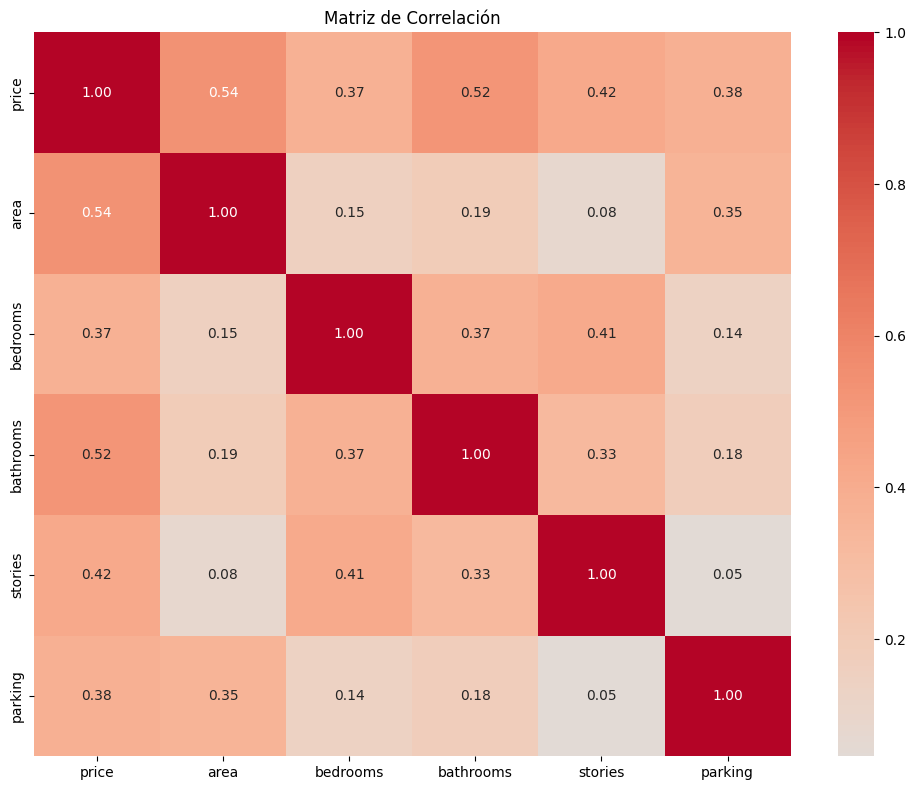

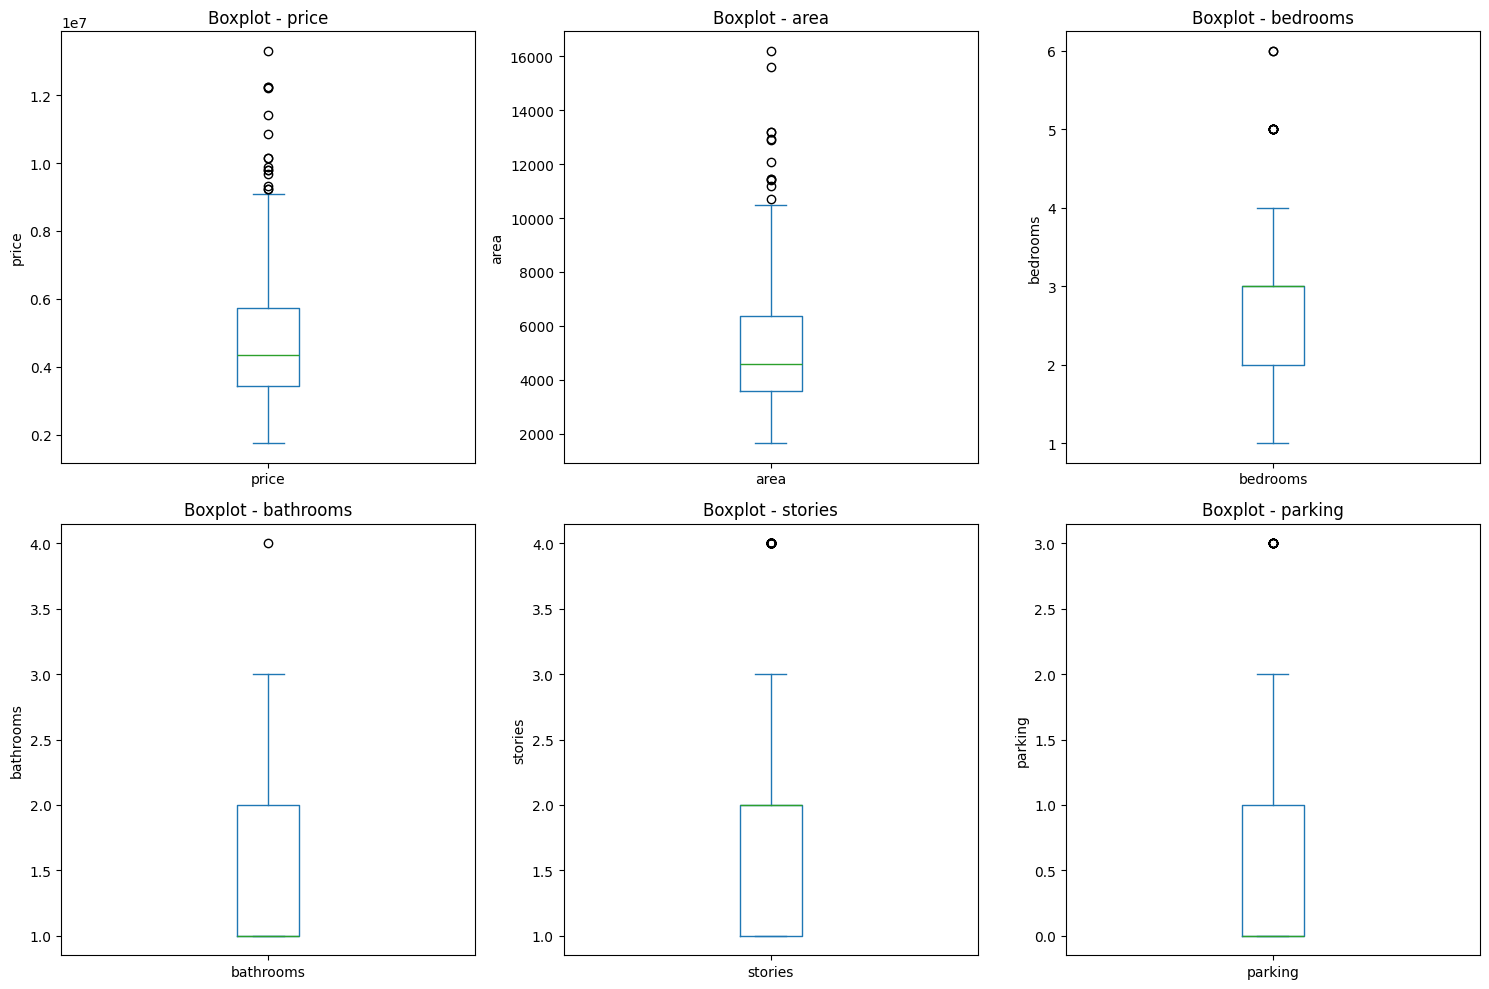


=== RESUMEN ===
El análisis de calidad de datos ha sido completado.
Se han identificado valores nulos, outliers y correlaciones entre variables.


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que df ya está cargado desde la celda anterior
# Si no, cargarlo de nuevo
df = pd.read_excel('data-housing.xlsx')

print("=== INFORME DE CALIDAD DE DATOS ===\n")

# 1. Información general del dataset
print("1. Información general:")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nEstadísticas descriptivas:")
print(df.describe())

# 2. Análisis de valores nulos
print("\n=== ANÁLISIS DE VALORES NULOS ===")
valores_nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(valores_nulos)
print(f"\nPorcentaje de valores nulos:")
print((valores_nulos / len(df) * 100).round(2))

# 3. Análisis de datos atípicos (outliers) usando el método IQR
print("\n=== ANÁLISIS DE DATOS ATÍPICOS (OUTLIERS) ===")
columnas_numericas = df.select_dtypes(include=[np.number]).columns

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"\n{col}:")
    print(f"  - Límite inferior: {limite_inferior:.2f}")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# 4. Análisis de datos extraños (valores fuera de rangos lógicos)
print("\n=== ANÁLISIS DE DATOS EXTRAÑOS ===")
print("Verificación de rangos lógicos:")
print(f"  - Área negativa: {(df['area'] < 0).sum()}")
print(f"  - Habitaciones negativas: {(df['bedrooms'] < 0).sum()}")
print(f"  - Baños negativos: {(df['bathrooms'] < 0).sum()}")
print(f"  - Precio negativo: {(df['price'] < 0).sum()}")

# 5. Análisis de correlaciones
print("\n=== ANÁLISIS DE CORRELACIONES ===")
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()
print("Matriz de correlación:")
print(matriz_correlacion)

# Correlaciones más fuertes con el precio
print("\nCorrelaciones con el precio (ordenadas):")
correlaciones_precio = matriz_correlacion['price'].sort_values(ascending=False)
print(correlaciones_precio)

# 6. Visualización de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# 7. Visualización de distribuciones y outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(columnas_numericas):
    if i < 6:
        df[col].plot(kind='box', ax=axes[i])
        axes[i].set_title(f'Boxplot - {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

print("\n=== RESUMEN ===")
print("El análisis de calidad de datos ha sido completado.")
print("Se han identificado valores nulos, outliers y correlaciones entre variables.")

8.Genera un modelo de regresión lineal. Para ello: 
    * Importa el estimador de regresión lineal de Scikit-learn. 
    * Divide los datos (80% train y 20% test). 
    * Crea una instancia del modelo de regresión lineal. 
    * Ajusta el modelo utilizando los datos de entrenamiento.



In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Seleccionar variables numéricas como features
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df['price']

# Dividir los datos en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear una instancia del modelo de regresión lineal
modelo = LinearRegression()

# Ajustar el modelo utilizando los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo de regresión lineal entrenado exitosamente.")
print(f"Intercepto: {modelo.intercept_:.2f}")
print("Coeficientes:")
for feature, coef in zip(X.columns, modelo.coef_):
    print(f"  {feature}: {coef:.2f}")

Modelo de regresión lineal entrenado exitosamente.
Intercepto: 51999.68
Coeficientes:
  area: 308.87
  bedrooms: 151246.75
  bathrooms: 1185731.71
  stories: 495100.76
  parking: 337660.83


9.Evalúa el modelo. Para ello: 
    * Utiliza los datos de entrenamiento y calcula métricas de evaluación, como el error cuadrado medio (MSE) o el coeficiente de determinación (R^2). Grafica los coeficientes. 
    * Utiliza los datos de prueba para realizar predicciones con el modelo entrenado, y evalúa el rendimiento del modelo comparando las predicciones con los valores reales.

=== EVALUACIÓN CON DATOS DE ENTRENAMIENTO ===
Error cuadrático medio (MSE): 1350008211326.58
Coeficiente de determinación (R²): 0.5622


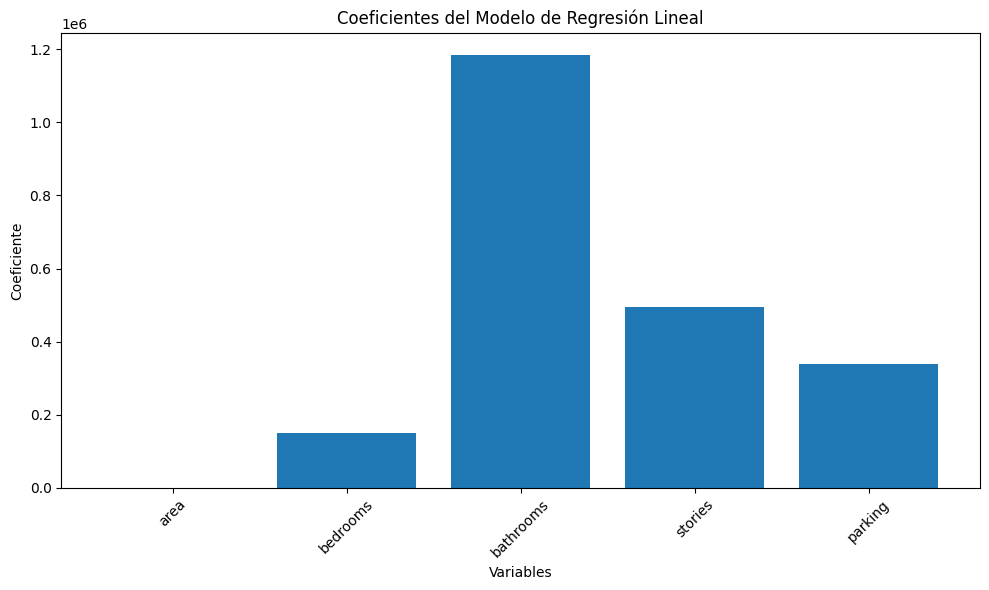


=== EVALUACIÓN CON DATOS DE PRUEBA ===
Error cuadrático medio (MSE): 2292721545725.36
Coeficiente de determinación (R²): 0.5464


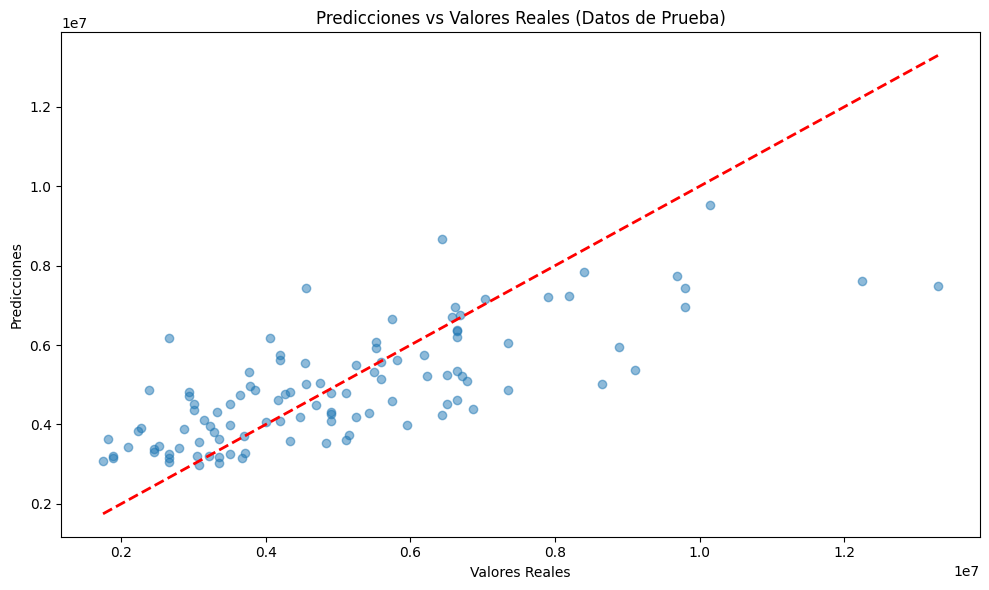


=== COMPARACIÓN DE PREDICCIONES VS VALORES REALES (Primeras 10 muestras) ===
   Valor Real    Predicción    Diferencia
0     4060000  6.178628e+06 -2.118628e+06
1     6650000  6.370141e+06  2.798591e+05
2     3710000  3.283148e+06  4.268518e+05
3     6440000  4.226008e+06  2.213992e+06
4     2800000  3.409686e+06 -6.096856e+05
5     4900000  4.262158e+06  6.378417e+05
6     5250000  5.493441e+06 -2.434405e+05
7     4543000  5.559898e+06 -1.016898e+06
8     2450000  3.373715e+06 -9.237154e+05
9     3353000  3.020513e+06  3.324868e+05


In [5]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluar el modelo con datos de entrenamiento
y_train_pred = modelo.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("=== EVALUACIÓN CON DATOS DE ENTRENAMIENTO ===")
print(f"Error cuadrático medio (MSE): {mse_train:.2f}")
print(f"Coeficiente de determinación (R²): {r2_train:.4f}")

# Graficar los coeficientes
plt.figure(figsize=(10, 6))
coeficientes = modelo.coef_
features = X.columns
plt.bar(features, coeficientes)
plt.xlabel('Variables')
plt.ylabel('Coeficiente')
plt.title('Coeficientes del Modelo de Regresión Lineal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluar el modelo con datos de prueba
y_test_pred = modelo.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n=== EVALUACIÓN CON DATOS DE PRUEBA ===")
print(f"Error cuadrático medio (MSE): {mse_test:.2f}")
print(f"Coeficiente de determinación (R²): {r2_test:.4f}")

# Comparar predicciones con valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (Datos de Prueba)')
plt.tight_layout()
plt.show()

# Mostrar algunas predicciones vs valores reales
print("\n=== COMPARACIÓN DE PREDICCIONES VS VALORES REALES (Primeras 10 muestras) ===")
comparacion = pd.DataFrame({
    'Valor Real': y_test.values[:10],
    'Predicción': y_test_pred[:10],
    'Diferencia': y_test.values[:10] - y_test_pred[:10]
})
print(comparacion.to_string())